In [1]:
from collections import namedtuple

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from vorpy.symplectic_integration.nonseparable_hamiltonian import integrate, heuristic_estimate_for_omega
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from tqdm import tqdm

from cgc.graph import ComputationalGraph, derivative
from cgc.optimizers import TwoStepsNGDptimizerForKF
from cgc.utils import KernelParameter as KP

from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")

pd.set_option("display.precision", 17)

np.int = int


# Experiment Configurations

In [2]:
N_TRAJICTORIES_TRAIN = 1
N_TRAJICTORIES_TEST = 50

N = 400
T_MAX = 80
OBSERVATIONS_END = 200
SPARSITY_FACTOR = 0.9
KFLOW_LEARNING = False
USE_SYMPLECTIC_INTEGERATION = False

H_KERNEL = "separable-polynomial"
H_KERNEL_PARAMS = {"constant": KP(1, learnable=False), "exponent": KP(3.0, learnable=False)}
H_KERNEL_NUGGET = 0.001

# The following is applied to all components of p in the system
P_KERNEL = "gaussian"
P_KERNEL_PARAMS = {"scale": KP(1.0, learnable=True)}
P_KERNEL_NUGGET = 1e-5

# The following is applied to all components of q in the system
Q_KERNEL = "gaussian"
Q_KERNEL_PARAMS = {"scale": KP(1.0, learnable=True)}
Q_KERNEL_NUGGET = 1e-5

TRUE_COEFS = jnp.asarray([0, 0, 0.5, 0, 0, 0, 0.5, 0])

TRAIN_BANDS = [(0.1, 0.3), (0.5, 0.7)]
TEST_BANDS = [(0.35, 0.45), (0.75, 1)]

In [3]:
def get_hamiltonian_from(graph: ComputationalGraph, Z):
    """Retunr a callable for the learned hamiltonina from CGC."""
    H_fn = graph._unknown_functions["H"]
    return lambda pq: H_fn._f(pq, H_fn.parameter(Z), H_fn.observation(Z))


In [4]:
def hamiltonian_symplectic_int(H_grad, initial_conditions, t, order=2, c=10):
    """Symplectically integerate a hamiltonina system."""
    dt = jnp.mean(jnp.diff(t))
    omega = heuristic_estimate_for_omega(delta=dt, order=order, c=c)
    dim = int(len(initial_conditions) / 2)

    dH_dp = lambda q, p: H_grad(jnp.hstack((p, q)))[:dim]
    dH_dq = lambda q, p: H_grad(jnp.hstack((p, q)))[dim:]

    init_conds = jnp.asarray(initial_conditions).reshape((2, -1))[::-1]

    pq_inverted = np.squeeze(integrate(
        initial_coordinates=init_conds,
        t_v=t,
        dH_dp=dH_dp,
        dH_dq=dH_dq,
        order=order,
        omega=omega
    ))

    if dim == 1:
        pq = pq_inverted[:, [1, 0]]
    else:
        pq_inverted_reshaped = np.reshape(pq_inverted, (-1, 4))
        pq = pq_inverted_reshaped[:, [2, 3, 0, 1]]

    return pq

In [5]:
def get_pq_from(graph: ComputationalGraph, Z):
    _, size = Z.shape
    dims = (size - 2) // 2

    p_fns = [graph._unknown_functions[f"p{index + 1 if dims > 1 else ''}"] for index in range(dims)]
    q_fns = [graph._unknown_functions[f"q{index + 1 if dims > 1 else ''}"] for index in range(dims)]   

    def pq_fn(t):
        ps = [p_fn._f(t, p_fn.parameter(Z), p_fn.observation(Z)) for p_fn in p_fns]
        qs = [q_fn._f(t, q_fn.parameter(Z), q_fn.observation(Z)) for q_fn in q_fns]

        return jnp.hstack(ps + qs)

    return pq_fn

In [6]:
def __reduce_mask(nd_mask):
        reduced_mask = nd_mask
        if nd_mask.ndim > 1:
            reduced_mask = np.multiply.reduce(nd_mask, axis=1).astype(bool)
        return reduced_mask

def two_steps_initialization(graph: ComputationalGraph, X, M, observations_end):

    _, pq_size = X.shape

    true_observations_mask = __reduce_mask(M[:observations_end, 1:pq_size - 1])

    H_est = get_hamiltonian_from(graph, X[:observations_end, :][true_observations_mask])
    pq_est = get_pq_from(graph, X[:observations_end, :][true_observations_mask])
    H_grad = jax.jit(jax.grad(H_est))

    init_point = X[observations_end - 1, 1:pq_size - 1]
    t = X[:, 0]

    if not USE_SYMPLECTIC_INTEGERATION:

        def ms_kernel_ode(pq, t):
            dims = (pq_size - 2) // 2
            grad_val = H_grad(pq)
            dpH = grad_val[0: dims]
            dqH = grad_val[dims: 2 * dims]

            return np.concatenate([-dqH, dpH])
        
        pq_2s = odeint(ms_kernel_ode, init_point, t[observations_end - 1:])
    else: 
        pq_2s = hamiltonian_symplectic_int(H_grad, init_point, t[observations_end - 1:])
    
    pq_interpolated = jax.jit(jax.vmap(pq_est))(t[:observations_end])

    X_initialized = X.copy()
    X_initialized[observations_end - 1:, 1:pq_size - 1] = pq_2s
    X_initialized[:observations_end, 1:pq_size - 1][~true_observations_mask] = pq_interpolated[~true_observations_mask, :]
    H_init = jax.jit(jax.vmap(H_est))(X_initialized[:, 1:pq_size - 1])
    X_initialized[:, pq_size - 1] = H_init

    _, separate_losses = graph._loss(X_initialized, X_initialized, M, return_separate=True)
    rkhs_order_magnitude = np.floor(np.log10(separate_losses.get("rkhs_norm")))
    unk_funcs_order_magnitude = np.floor(np.log10(separate_losses.get("unknown_funcs_loss")))
    constraints_order_magnitude = np.floor(np.log10(separate_losses.get("constraints_loss")))
    data_compliance_order_magnitude = np.floor(np.log10(separate_losses.get("data_compliance_loss")))

    unknown_functions_loss_multiplier = 10 ** (rkhs_order_magnitude - unk_funcs_order_magnitude)
    constraint_loss_multiplier = 10 ** (rkhs_order_magnitude - constraints_order_magnitude)
    data_compliance_loss_multiplier = 10 ** (rkhs_order_magnitude - data_compliance_order_magnitude)

    return X_initialized, unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier


In [7]:
from cgc.kernels.factory import KernelsFactory

def _adjust_y_train_shape(matrix, y_train):
    _, matrix_trainling_dim_size = matrix.shape
    observation_leading_dim_size, *_ = y_train.shape

    if matrix_trainling_dim_size != observation_leading_dim_size:
        y_train = jnp.reshape(y_train, (matrix_trainling_dim_size, ), order='F')

    return y_train

def _adjust_sims_shape(matrix, sims):
    _, matrix_trainling_dim_size = matrix.shape
    *_, sims_trailing_dim_size = sims.shape

    if matrix_trainling_dim_size != sims_trailing_dim_size:
        sims = jnp.reshape(sims, (matrix_trainling_dim_size, ), order='F')

    return sims


def one_step_hamiltonian(Z, observations_end, num_trajectories=1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET, linear_functional=jax.jacobian)

    _, pq_size = Z.shape
    ndims = (pq_size - 4) // 2
    p_start, p_end = 3, ndims + 3
    q_start, q_end = ndims + 3, 2 * ndims + 3

    T_train = Z[:observations_end * num_trajectories, 0:3]
    P_train = Z[:observations_end * num_trajectories, p_start:p_end]
    Q_train = Z[:observations_end * num_trajectories, q_start:q_end]

    def p(t):
        sims = p_kernel(t, T_train)
        matrix = p_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, P_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    def q(t):
        sims = q_kernel(t, T_train)
        matrix = q_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, Q_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    p_dot = jax.jacobian(p)
    q_dot = jax.jacobian(q)

    PQ_train = jnp.concatenate((P_train, Q_train), axis=1)
    QP_DOT_train = jnp.concatenate((
            jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_train))[:, 0],
            jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_train))[:, 0]
        )
    )

    H_matrix = H_kernel.matrix(PQ_train)
    H_y_train = _adjust_y_train_shape(H_matrix, QP_DOT_train)
    inv = jnp.linalg.solve(H_matrix, H_y_train)

    def H(pq):
        sims = H_kernel(pq, PQ_train)

        sims = _adjust_sims_shape(H_matrix, sims)

        return jnp.squeeze(sims @ inv)
    
    return H


def two_steps_pqH(X, M, observations_end, use_T_in_second_step=False, num_trajectories=1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET, linear_functional=jax.jacobian)


    _, pq_size = X.shape
    ndims = (pq_size - 4) // 2
    p_start, p_end = 3, ndims + 3
    q_start, q_end = ndims + 3, 2 * ndims + 3
    true_observations_mask = __reduce_mask(M[:observations_end * num_trajectories, 3:pq_size - 1])

    T_ghost = X[:observations_end * num_trajectories, 0:3]
    T_train = X[:observations_end * num_trajectories, 0:3][true_observations_mask]
    P_train = X[:observations_end * num_trajectories, p_start:p_end][true_observations_mask]
    Q_train = X[:observations_end * num_trajectories, q_start:q_end][true_observations_mask]

    def p(t):
        sims = p_kernel(t, T_train)
        matrix = p_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, P_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    def q(t):
        sims = q_kernel(t, T_train)
        matrix = q_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, Q_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    p_dot = jax.jacobian(p)
    q_dot = jax.jacobian(q)

    if use_T_in_second_step:
        PQ_train = jnp.concatenate((jax.jit(jax.vmap(p))(T_ghost), jax.jit(jax.vmap(q))(T_ghost)), axis=1)
        QP_DOT_train = jnp.concatenate((
                jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_ghost))[:, 0][:, jnp.newaxis], 
                jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_ghost))[:, 0][:, jnp.newaxis])
            , axis=1)
    else:
        PQ_train = jnp.concatenate((P_train, Q_train), axis=1)
        QP_DOT_train = jnp.concatenate((
                jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_train))[:, 0],
                jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_train))[:, 0]
            )
        )


    H_matrix = H_kernel.matrix(PQ_train)
    H_y_train = _adjust_y_train_shape(H_matrix, QP_DOT_train)
    inv = jnp.linalg.solve(H_matrix, H_y_train)

    print(H_matrix.device, H_y_train.device, inv.device)
    def H(pq):
        sims = H_kernel(pq, PQ_train)

        sims = _adjust_sims_shape(H_matrix, sims)

        return jnp.squeeze(sims @ inv)
    
    return p, q, H


def integerate_H_est(H_est, init_point, time, dims=1):
    
    H_grad = jax.jit(jax.grad(H_est))
    
    def kernel_ode(pq, t):
        grad_val = H_grad(pq)
        dpH = grad_val[0: dims]
        dqH = grad_val[dims: 2 * dims]

        return np.concatenate([-dqH, dpH])
    
    pq = odeint(kernel_ode, init_point, time)

    return pq

def initialize_X_for_one_step(X, M, p_fn, q_fn, H_fn):
    
    _, pq_size = X.shape
    X_initialized = X.copy()
    extra_steps = N - OBSERVATIONS_END

    T = X[:, 0]
    true_observations_mask = __reduce_mask(M[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 3:pq_size - 1])
    
    for i in range(N_TRAJICTORIES_TRAIN):

        init_point = X[OBSERVATIONS_END * (i + 1)  - 1, 3:pq_size - 1]
        
        extrapolation_time_start = OBSERVATIONS_END * N_TRAJICTORIES_TRAIN
        extrapolation_time = np.concatenate((
            np.reshape(T[OBSERVATIONS_END * (i + 1) - 1], (1,)), 
            T[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1)]
        ), axis=0)

        pq_2s = integerate_H_est(H_fn, init_point, extrapolation_time)

        X_initialized[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1), 3:pq_size - 1] = pq_2s[1:, :]

    pq_interpolated = jnp.concatenate((
            jax.jit(jax.vmap(p_fn))(X[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 0:3]),
            jax.jit(jax.vmap(q_fn))(X[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 0:3])
        ),
        axis=1
    )

    X_initialized[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 3:pq_size - 1][~true_observations_mask] = pq_interpolated[~true_observations_mask, :]
    H_init = jax.jit(jax.vmap(H_fn))(X_initialized[:, 3:pq_size - 1])
    X_initialized[:, pq_size - 1] = H_init

    return X_initialized


def initalize_one_step_loss_multipliers(graph, X_init, M):
    _, separate_losses = graph._loss(X_init, X_init, M, return_separate=True)
    rkhs_order_magnitude = np.floor(np.log10(separate_losses.get("rkhs_norm")))
    unk_funcs_order_magnitude = np.floor(np.log10(separate_losses.get("unknown_funcs_loss")))
    constraints_order_magnitude = np.floor(np.log10(separate_losses.get("constraints_loss")))
    data_compliance_order_magnitude = np.floor(np.log10(separate_losses.get("data_compliance_loss")))

    unknown_functions_loss_multiplier = 10 ** (rkhs_order_magnitude - unk_funcs_order_magnitude)
    constraint_loss_multiplier = 10 ** (rkhs_order_magnitude - constraints_order_magnitude)
    data_compliance_loss_multiplier = 10 ** (rkhs_order_magnitude - data_compliance_order_magnitude)

    return unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier

In [8]:
from sklearn.preprocessing import PolynomialFeatures
import re

def get_seprable_H_coef(Z, observations_end, num_trajectories = 1):
    p_kernel = KernelsFactory.create(P_KERNEL, P_KERNEL_PARAMS, P_KERNEL_NUGGET)
    q_kernel = KernelsFactory.create(Q_KERNEL, Q_KERNEL_PARAMS, Q_KERNEL_NUGGET)
    H_kernel = KernelsFactory.create(H_KERNEL, H_KERNEL_PARAMS, H_KERNEL_NUGGET, linear_functional=jax.jacobian)

    _, pq_size = Z.shape
    ndims = (pq_size - 4) // 2
    p_start, p_end = 3, ndims + 3
    q_start, q_end = ndims + 3, 2 * ndims + 3

    H_estimated = Z[:observations_end * num_trajectories, -1]
    T_train = Z[:observations_end * num_trajectories, 0:3]
    P_train = Z[:observations_end * num_trajectories, p_start:p_end]
    Q_train = Z[:observations_end * num_trajectories, q_start:q_end]
    PQ_train = jnp.concatenate((P_train, Q_train), axis=1)


    def p(t):
        sims = p_kernel(t, T_train)
        matrix = p_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, P_train)

        return sims @ jnp.linalg.solve(matrix, y_train)
    
    def q(t):
        sims = q_kernel(t, T_train)
        matrix = q_kernel.matrix(T_train)

        sims = _adjust_sims_shape(matrix, sims)
        y_train = _adjust_y_train_shape(matrix, Q_train)

        return sims @ jnp.linalg.solve(matrix, y_train)


    p_dot = jax.jacobian(p)
    q_dot = jax.jacobian(q)

    QP_DOT_train = jnp.concatenate((
                jnp.squeeze(jax.jit(jax.vmap(q_dot))(T_train))[:, 0],
                jnp.squeeze(-jax.jit(jax.vmap(p_dot))(T_train))[:, 0]
            )
        )

    H_k = H_kernel.matrix(PQ_train)

    #poly_features = PolynomialFeatures(degree=3)
    #mapped_features = np.concatenate((
    #    poly_features.fit_transform(P_train),
    #    poly_features.fit_transform(Q_train)
    #), axis=1)

    def grad_psi(pq):
        p, q = pq
        return jnp.array([
            [0, 1, 2 * p, 3 * (p ** 2), 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 1, 2 * q, 3 * (q ** 2)]
        ])
    
    mapped_features = jax.vmap(grad_psi)(PQ_train)
    m, *_ = H_k.shape

    mapped_features = jnp.reshape(mapped_features, (m, 8), order='F')


    w_p = mapped_features.T @ jnp.linalg.solve(H_k, QP_DOT_train)

    def _replace_func(new_var, text):
        def repl(match):
            num = int(match.group(1))
            return f"{new_var}{num+1}"
    
        return re.sub(r"x(\d+)", repl, text)
    
    #w_true = np.zeros_like(w_p)
    #for i, term in enumerate(terms):
    #    if term in true_coefs:
    #        w_true[i] = true_coefs[term]
    #    if term == '1':
    #        w_p = w_p.at[i].set(0.0)

    print(w_p)
            
    return w_p



In [9]:
def mse(truth: np.ndarray, predictions: np.ndarray, ):
    return np.mean((predictions - truth) ** 2)

def relative_error(truth: np.ndarray, predictions: np.ndarray):
    return np.linalg.norm((truth - predictions), ord=2) / np.linalg.norm(truth, ord=2)

# Mass-Spring System

## Data Generation

In [10]:
def ms_system_ode(pq, t):
    p, q = pq
    h_grad = [
        -q,
        p
    ]

    return h_grad

t = np.linspace(0, T_MAX, N)

def generate_trajectory(p0q0):
    return odeint(ms_system_ode, p0q0, t)

In [11]:
rng = np.random.default_rng(0)

trajectories = []
test_trajectories = []
training_trajectories = []
test_initial_conds = []
training_initial_conds = []

generated_test_trajectories_count = 0
generated_train_trajectories_count = 0

attempts = 0

while True:

    if (generated_test_trajectories_count == N_TRAJICTORIES_TEST) and (generated_train_trajectories_count == N_TRAJICTORIES_TRAIN):
        break

    p0 = rng.uniform(-1., 1.)
    q0 = rng.uniform(-1., 1.)

    energy = 0.5 * (p0 ** 2 + q0 ** 2)

    is_training_trajectory = any(low <= energy <= high for low, high in TRAIN_BANDS)
    is_test_trajectory = any(low <= energy <= high for low, high in TEST_BANDS)

    if is_test_trajectory or is_training_trajectory:
        assert is_test_trajectory != is_training_trajectory

    if is_training_trajectory and (generated_train_trajectories_count < N_TRAJICTORIES_TRAIN):
        training_initial_conds.append((p0, q0))
        training_trajectories.append(generate_trajectory((p0, q0)))
        generated_train_trajectories_count += 1

    if is_test_trajectory and (generated_test_trajectories_count < N_TRAJICTORIES_TEST):
        test_initial_conds.append((p0, q0))
        test_trajectories.append(generate_trajectory((p0, q0)))
        generated_test_trajectories_count += 1

    attempts += 1


print(f"Generated {N_TRAJICTORIES_TEST} test trajectories and {N_TRAJICTORIES_TRAIN} training trajectories in {attempts} attempts.")

Generated 50 test trajectories and 1 training trajectories in 324 attempts.


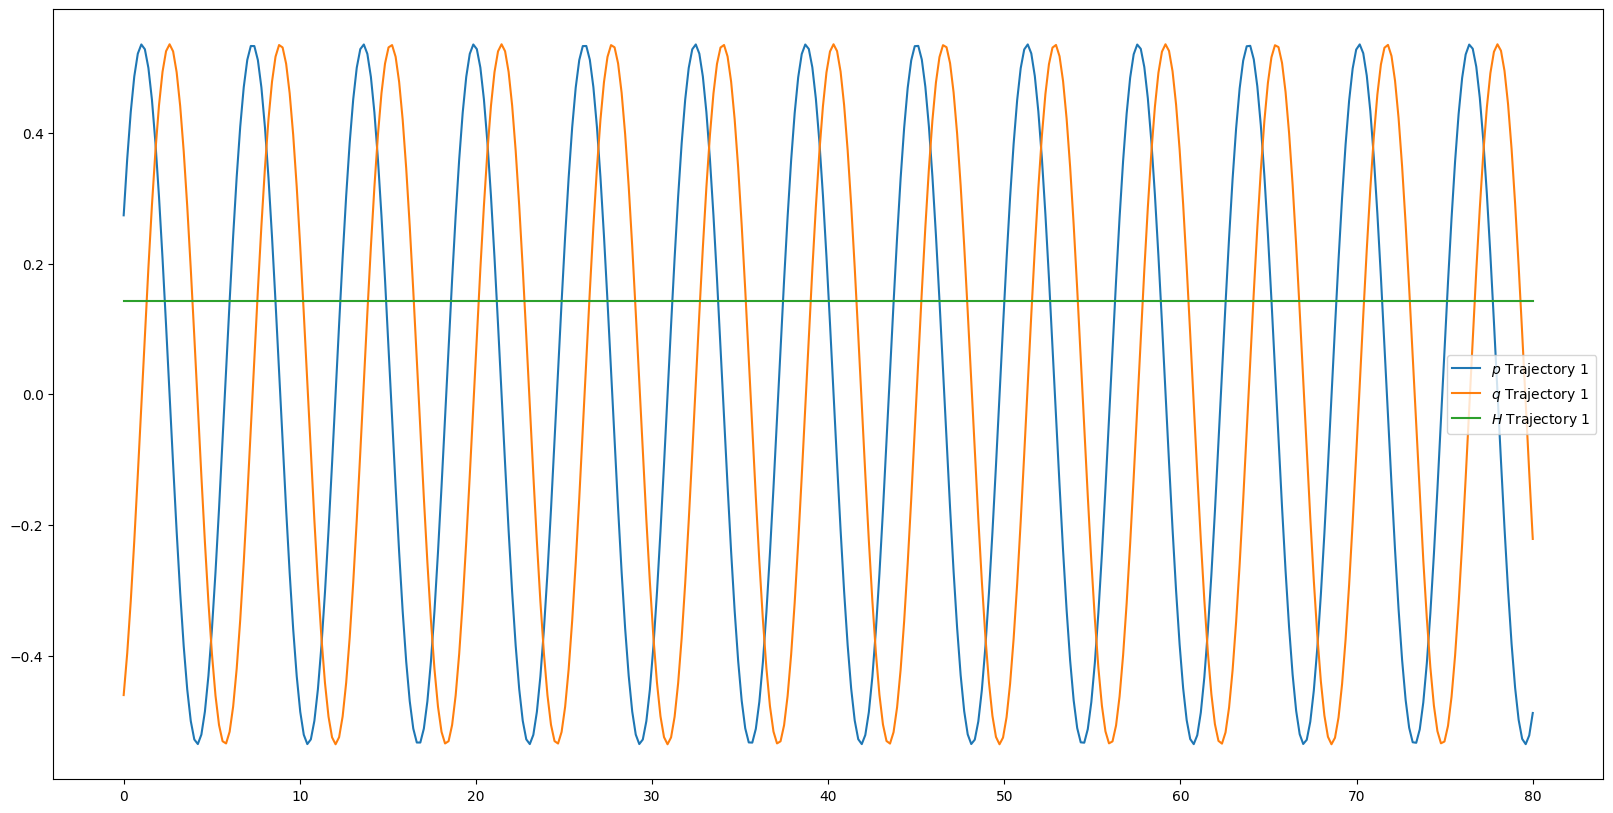

In [12]:
plt.figure(figsize=(20, 10))

for k, pq in enumerate(training_trajectories):

    p, q = pq.T
    H = 0.5 * (p ** 2 + q ** 2)

    i, j = k // 2, k % 2
    plt.plot(t, p, label=f"$p$ Trajectory {k + 1}")
    plt.plot(t, q, label=f"$q$ Trajectory {k + 1}")
    plt.plot(t, H, label=f"$H$ Trajectory {k + 1}")
    plt.legend()


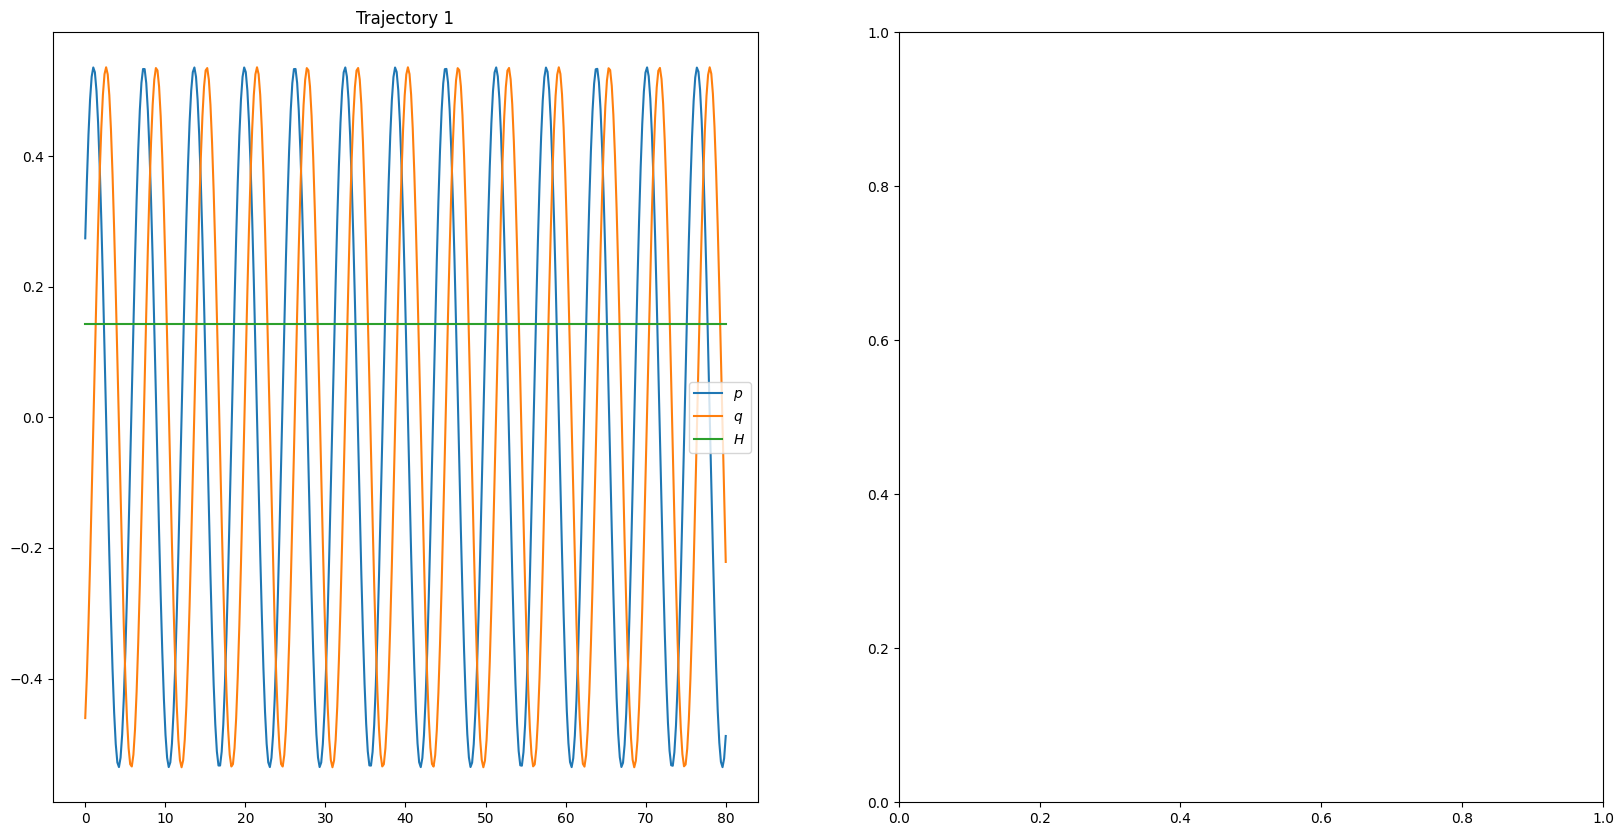

In [13]:
fig, axes = plt.subplots(np.ceil(N_TRAJICTORIES_TRAIN / 2).astype(int), 2, figsize=(20, 10 * np.ceil(N_TRAJICTORIES_TRAIN / 2).astype(int)))

for k, pq in enumerate(training_trajectories):

    p, q = pq.T
    H = 0.5 * (p ** 2 + q ** 2)

    i, j = k // 2, k % 2

    axes_index = (i, j) if axes.ndim > 1 else (k, )

    axes[axes_index].plot(t, p, label=f"$p$")
    axes[axes_index].plot(t, q, label=f"$q$")
    axes[axes_index].plot(t, H, label=f"$H$")
    axes[axes_index].set_title(f"Trajectory {k + 1}")
    axes[axes_index].legend()

In [14]:
rng = np.random.default_rng(0)

sparse_mask = rng.choice([False, True], p=[SPARSITY_FACTOR, 1 - SPARSITY_FACTOR], size=OBSERVATIONS_END)
sparse_mask[-1] = True

all_trajectories_observed = []
all_trajectories_hidden = []
all_p0q0_observed = []
all_p0q0_hidden = []
all_H_observed = []
all_H_hidden = []

for p0q0, pq in zip(training_initial_conds, training_trajectories):
    p, q = pq.T
    H = 0.5 * (p ** 2 + q ** 2)

    all_trajectories_observed.append(pq[:OBSERVATIONS_END, :])
    all_trajectories_hidden.append(pq[OBSERVATIONS_END:, :])
    all_p0q0_observed.append(np.tile(p0q0, (OBSERVATIONS_END, 1)))
    all_p0q0_hidden.append(np.tile(p0q0, (N - OBSERVATIONS_END, 1)))
    all_H_observed.append(H[:OBSERVATIONS_END, np.newaxis])
    all_H_hidden.append(H[OBSERVATIONS_END:, np.newaxis])


X_true = np.concatenate([
    np.concatenate(
        [np.tile(t[:OBSERVATIONS_END], N_TRAJICTORIES_TRAIN)[:, np.newaxis], 
        np.tile(t[OBSERVATIONS_END:], N_TRAJICTORIES_TRAIN)[:, np.newaxis]],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_p0q0_observed, axis=0), 
        np.concatenate(all_p0q0_hidden, axis=0)],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_trajectories_observed, axis=0), 
        np.concatenate(all_trajectories_hidden, axis=0)],
        axis=0
    ),
    np.concatenate(
        [np.concatenate(all_H_observed, axis=0),
        np.concatenate(all_H_hidden, axis=0)],
        axis=0
    )],
    axis=1
)

M = np.ones_like(X_true).astype(bool)

for i in range(N_TRAJICTORIES_TRAIN):
    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 3] = sparse_mask
    M[OBSERVATIONS_END * i: OBSERVATIONS_END * (i + 1), 4] = sparse_mask

M[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3:5] = False
M[:, 5] = False

X = np.full_like(X_true, fill_value=0)
X[M] = X_true[M]

In [15]:
X.shape

(400, 6)

In [16]:
ms_graph = ComputationalGraph(observables_order=["t", "p0", "q0", "p", "q", "H"])

ms_graph.add_observable("t")
ms_graph.add_observable("p0")
ms_graph.add_observable("q0")

ms_graph.add_aggregator(["t", "p0", "q0"], "tp0q0")

ms_graph.add_unknown_fn("tp0q0", "q", alpha=P_KERNEL_NUGGET, kernel=P_KERNEL, kernel_parameters=P_KERNEL_PARAMS)
ms_graph.add_unknown_fn("tp0q0", "p", alpha=Q_KERNEL_NUGGET, kernel=Q_KERNEL, kernel_parameters=Q_KERNEL_PARAMS)

ms_graph.add_known_fn("p", "p_grad", derivative)
ms_graph.add_known_fn("q", "q_grad", derivative)

ms_graph.add_known_fn("p_grad", "p_dot", lambda p_grad: p_grad[:, 0])
ms_graph.add_known_fn("q_grad", "q_dot", lambda q_grad: q_grad[:, 0])

ms_graph.add_known_fn("p_dot", "-p_dot", lambda p_dot: -p_dot)

ms_graph.add_aggregator(["q_dot", "-p_dot"], "qp_dot")

ms_graph.add_aggregator(["p", "q"], "pq")
ms_graph.add_unknown_fn("pq", "H", linear_functional=jax.jacobian, observations="qp_dot", alpha=H_KERNEL_NUGGET, kernel=H_KERNEL, kernel_parameters=H_KERNEL_PARAMS)
ms_graph.add_known_fn("H", "grad_H", derivative)

ms_graph.add_aggregator(["q_dot", "grad_H"], "(q_dot, grad_H)")
ms_graph.add_aggregator(["p_dot", "grad_H"], "(p_dot, grad_H)")

def p_dot_constraint(p_dot_grad_H):
    p_dot, grad_H = p_dot_grad_H[:, 0], p_dot_grad_H[:, 1:]
    return p_dot + grad_H[:, 1]

def q_dot_constraint(q_dot_grad_H):
    q_dot, grad_H = q_dot_grad_H[:, 0], q_dot_grad_H[:, 1:]
    return q_dot - grad_H[:, 0]

ms_graph.add_constraint("(p_dot, grad_H)", "W1", p_dot_constraint)
ms_graph.add_constraint("(q_dot, grad_H)", "W2", q_dot_constraint)

In [17]:
p_2s, q_2s, H_2s = two_steps_pqH(X, M, OBSERVATIONS_END, num_trajectories=N_TRAJICTORIES_TRAIN, use_T_in_second_step=True)
X_init = initialize_X_for_one_step(X, M, p_2s, q_2s, H_2s)
unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier = initalize_one_step_loss_multipliers(ms_graph, X_init, M)

cpu:0 cpu:0 cpu:0


## Two-Steps Seen Trajectories Extrapolation

In [18]:
two_steps_mse_p = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3])
two_steps_mse_q = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4])

two_steps_re_p = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3]) * 100
two_steps_re_q = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4], X_init[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4]) * 100

pd.DataFrame({"P": [two_steps_mse_p, two_steps_re_p], "Q": [two_steps_mse_q, two_steps_re_q]}, index=["MSE", "Relative"])

,P,Q
MSE,0.29120380688262448,0.27413087567236011
Relative,142.18139869923084007,138.46658355602613710


## Two-Steps Unseen Trajectories Extrapolation

In [19]:
two_steps_p_mse_errors = []
two_steps_p_re_errors = []
two_steps_q_mse_errors = []
two_steps_q_re_errors = []

t = np.linspace(0, T_MAX, N)

for init_cond, pq_true in tqdm(zip(test_initial_conds, test_trajectories)):

    pq_pred = integerate_H_est(H_2s, init_cond, t)
    two_steps_p_mse_errors.append(mse(pq_true[:, 0], pq_pred[:, 0]))
    two_steps_p_re_errors.append(relative_error(pq_true[:, 0], pq_pred[:, 0]) * 100)
    two_steps_q_mse_errors.append(mse(pq_true[:, 1], pq_pred[:, 1]))
    two_steps_q_re_errors.append(relative_error(pq_true[:, 1], pq_pred[:, 1]) * 100)

pd.DataFrame({
    "P": [
        np.mean(two_steps_p_mse_errors), np.min(two_steps_p_mse_errors), np.max(two_steps_p_mse_errors), 
        np.mean(two_steps_p_re_errors), np.min(two_steps_p_re_errors), np.max(two_steps_p_re_errors)
    ], 
    "Q": [
        np.mean(two_steps_q_mse_errors), np.min(two_steps_q_mse_errors), np.max(two_steps_q_mse_errors), 
        np.mean(two_steps_q_re_errors), np.min(two_steps_q_re_errors), np.max(two_steps_q_re_errors)
    ]
}, index=["MSE avg.", "MSE min.", "MSE max.", "Relative avg.", "Relative min.", "Relative max."])

50it [00:15,  3.19it/s]


,P,Q
MSE avg.,0.90434183120539202,0.89583027966907691
MSE min.,0.66350409378175312,0.65707545807792211
MSE max.,1.80188188052979759,1.78602434508308128
Relative avg.,138.92792121631066493,138.29237557329813058
Relative min.,135.81074212187050421,135.54678787552353469
Relative max.,142.06079557545646708,141.73970804735239426


## Two-Steps Recovered Hamiltonian Coeffcients Error

In [20]:
estimated_coefs = get_seprable_H_coef(X_init, OBSERVATIONS_END, N_TRAJICTORIES_TRAIN)
relative_error(TRUE_COEFS, estimated_coefs)

[ 0.         -0.0123382   0.15148397  0.00946528  0.          0.00164894
  0.15450875 -0.00995912]


np.float64(0.6945089695659145)

In [21]:
ms_graph.set_loss_multipliers(unknown_functions_loss_multiplier, constraint_loss_multiplier, data_compliance_loss_multiplier)

In [22]:
Z = ms_graph.complete(
    X_init[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, :], 
    M[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, :], 
    OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, optimizer="l-bfgs-b", learn_parameters=False, n_rounds=1)

 Loss: 12468.2124:   1%|          | 5632/1000000 [04:37<13:37:54, 20.26it/s]   


In [29]:
H_est = one_step_hamiltonian(Z, OBSERVATIONS_END, num_trajectories=N_TRAJICTORIES_TRAIN)
#H_est = get_hamiltonian_from(ms_graph, Z)
H_grad = jax.jit(jax.grad(H_est))
_, pq_size = Z.shape

T = X[:, 0:3]
Z_new = np.asarray(X).copy()
extra_steps = N - OBSERVATIONS_END 
for i in range(N_TRAJICTORIES_TRAIN):

    init_point = Z[OBSERVATIONS_END * (i + 1)  - 1, 3:pq_size - 1]

    def kernel_ode(pq, t):
        dims = (pq_size - 4) // 2
        grad_val = H_grad(pq)
        dpH = grad_val[0: dims]
        dqH = grad_val[dims: 2 * dims]

        return np.concatenate([-dqH, dpH])
        
    extrapolation_time_start = OBSERVATIONS_END * N_TRAJICTORIES_TRAIN
    extrapolation_time = np.concatenate((
        np.reshape(T[OBSERVATIONS_END * (i + 1) - 1, 0], (1,)), 
        T[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1), 0]
    ), axis=0)

    pq_2s = odeint(kernel_ode, init_point, extrapolation_time)

    Z_new[extrapolation_time_start + extra_steps * i: extrapolation_time_start + extra_steps * (i + 1), 3:pq_size - 1] = pq_2s[1:, :]


Z_new[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 3:pq_size - 1] = Z[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, 3:pq_size - 1]
Z_new[:OBSERVATIONS_END * N_TRAJICTORIES_TRAIN, -1] = Z[:, -1]
Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, pq_size - 1] = jax.jit(jax.vmap(H_est))(Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3:pq_size - 1])

## CGC Seen Trajectories Extrapolation

In [30]:
one_step_mse_p = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3])
one_step_mse_q = mse(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4])

one_step_re_p = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 3]) * 100
one_step_re_q = relative_error(X_true[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4], Z_new[OBSERVATIONS_END * N_TRAJICTORIES_TRAIN:, 4]) * 100

pd.DataFrame({"P": [one_step_mse_p, one_step_re_p], "Q": [one_step_mse_q, one_step_re_q]}, index=["MSE", "Relative"]) 

,P,Q
MSE,0.00000020667563067,0.00000021654531820
Relative,0.11978126461980536,0.12306665582766539


## CGC Unseen Trajectories Extrapolation

In [31]:
one_step_p_mse_errors = []
one_step_p_re_errors = []
one_step_q_mse_errors = []
one_step_q_re_errors = []

t = np.linspace(0, T_MAX, N)

for init_cond, pq_true in tqdm(zip(test_initial_conds, test_trajectories)):

    pq_pred = integerate_H_est(H_est, init_cond, t)
    one_step_p_mse_errors.append(mse(pq_true[:, 0], pq_pred[:, 0]))
    one_step_p_re_errors.append(relative_error(pq_true[:, 0], pq_pred[:, 0]) * 100)
    one_step_q_mse_errors.append(mse(pq_true[:, 1], pq_pred[:, 1]))
    one_step_q_re_errors.append(relative_error(pq_true[:, 1], pq_pred[:, 1]) * 100)

pd.DataFrame({
    "P": [
        np.mean(one_step_p_mse_errors), np.min(one_step_p_mse_errors), np.max(one_step_p_mse_errors), 
        np.mean(one_step_p_re_errors), np.min(one_step_p_re_errors), np.max(one_step_p_re_errors)
    ], 
    "Q": [
        np.mean(one_step_q_mse_errors), np.min(one_step_q_mse_errors), np.max(one_step_q_mse_errors), 
        np.mean(one_step_q_re_errors), np.min(one_step_q_re_errors), np.max(one_step_q_re_errors)
    ]
}, index=["MSE avg.", "MSE min.", "MSE max.", "Relative avg.", "Relative min.", "Relative max."])

50it [00:16,  3.08it/s]


,P,Q
MSE avg.,0.00000322537339322,0.00000323476005835
MSE min.,0.00000206284052631,0.00000210700518393
MSE max.,0.00000695670685073,0.00000725417390448
Relative avg.,0.26047941336475389,0.26123314400766995
Relative min.,0.23867943116789372,0.23567086444157551
Relative max.,0.29424461742890301,0.30424789849688844


In [32]:
estimated_coefs = get_seprable_H_coef(Z, OBSERVATIONS_END, N_TRAJICTORIES_TRAIN)

print(relative_error(TRUE_COEFS, estimated_coefs))

[ 0.00000000e+00 -1.47341471e-05  1.66630524e-01 -3.61670930e-05
  0.00000000e+00  6.20173117e-06  1.66684228e-01 -1.19193481e-04]
0.6666852745169275
